# Figure 10 — Human keratinocytes on LQ-FL vs SQ-FL feeders

Panels:

- **a**: UMAP of all cells, coloured by predicted keratinocyte cluster
- **b**: UMAP, LQ-FL condition only, same colour scheme
- **c**: UMAP, SQ-FL condition only, same colour scheme
- **d**: Dot plot of marker genes × clusters (z-scored mean expression)
- **e**: % cells per cluster, grouped by condition, with per-sample dots overlaid

Inputs (preprocessed upstream):
- `integrated_seurat_object_FINAL.rds` — integrated Seurat object with `predicted_celltype`
  (`H`/`M`/`P`/`TD1`/`TD2`), `condition` (`Control`/`Stressed`), and `sample`
  (`K74_Control`/`K86_Control`/`K74_Stressed`/`K86_Stressed`).

**Structure**:
1. Imports / output dir
2. *(Optional)* Section 0 — full Seurat integration pipeline that builds the input object.
   Default OFF.
3. Section 1 — Load integrated object
4. Display renames + palette
5. Panels a, b, c (UMAPs)
6. Panel d (marker dot plot)
7. Panel e (% cells per cluster bar plot with replicates)

**Display renames** (matching manuscript labels):
- `predicted_celltype`: `H` → `Holoclone`, `M` → `Meroclone`, `P` → `Paraclone`,
  `TD1` → `Terminal Diff.1`, `TD2` → `Terminal Diff.2`
- `condition`: `Control` → `LQ-FL`, `Stressed` → `SQ-FL`

The renames are stored in new metadata columns; the originals stay untouched.

## Imports

In [1]:
suppressPackageStartupMessages({
    library(Seurat)
    library(ggplot2)
    library(dplyr)
    library(tidyr)
    library(stringr)
    library(forcats)
})

# Output directory for the saved figure SVGs (matches the convention used by figs 1, 3, 6, 7, 9)
out_dir <- '../manuscript_figures/figure_10'
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

dims <- function(width, height) {
    options(repr.plot.width = width, repr.plot.height = height)
}

Warning message:
“package ‘forcats’ was built under R version 4.2.3”


## Section 0 — Build integrated Seurat object (run once, then skip)

Full Seurat integration pipeline: read 10x matrices, clean human-only genes, QC + IQR
filter, normalize per sample, anchor-based integration, cell-cycle regression, PCA / UMAP /
clustering. Set `RUN_BUILD <- TRUE` to run; default `FALSE` so re-running the notebook
doesn't redo the expensive pipeline.

Label transfer from a mouse-derived reference (which produces `predicted_celltype`)
happens separately upstream of this notebook — see the integration pipeline outside the
main figure-generation flow.

In [ ]:
RUN_BUILD <- FALSE   # set to TRUE on first run

if (RUN_BUILD) {
    # ---- Read filtered 10x matrices ----
    K74_Control  <- Read10X_h5('../../data/Feeder_scdata/SQ-K74B/filtered_feature_bc_matrix.h5')
    K86_Control  <- Read10X_h5('../../data/Feeder_scdata/SQ-K86B/filtered_feature_bc_matrix.h5')
    K74_Stressed <- Read10X_h5('../../data/Feeder_scdata/LQ-K74S/filtered_feature_bc_matrix.h5')
    K86_Stressed <- Read10X_h5('../../data/Feeder_scdata/LQ-K86S/filtered_feature_bc_matrix.h5')

    # ---- Keep only human genes, strip prefix + version ----
    clean_human_genes <- function(mat) {
        human_genes      <- grep('^GRCh38_', rownames(mat), value = TRUE)
        mat              <- mat[human_genes, ]
        rownames(mat)    <- gsub('^GRCh38_', '', rownames(mat))
        rownames(mat)    <- gsub('\\..*', '', rownames(mat))
        mat
    }
    K74_Control  <- clean_human_genes(K74_Control)
    K86_Control  <- clean_human_genes(K86_Control)
    K74_Stressed <- clean_human_genes(K74_Stressed)
    K86_Stressed <- clean_human_genes(K86_Stressed)

    # ---- Create Seurat objects ----
    obj.list <- list(
        CreateSeuratObject(K74_Control,  project = 'K74_Control'),
        CreateSeuratObject(K86_Control,  project = 'K86_Control'),
        CreateSeuratObject(K74_Stressed, project = 'K74_Stressed'),
        CreateSeuratObject(K86_Stressed, project = 'K86_Stressed')
    )

    # ---- QC + IQR filter per sample ----
    calc_qc <- function(obj) {
        obj[['percent.mt']] <- PercentageFeatureSet(obj, pattern = '^MT-')
        obj
    }
    filter_outliers <- function(obj) {
        df <- obj@meta.data
        limits <- function(x) {
            qnt <- quantile(x, probs = c(.25, .75))
            iqr <- qnt[2] - qnt[1]
            c(lower = qnt[1] - 1.5 * iqr, upper = qnt[2] + 1.5 * iqr)
        }
        feat_lim  <- limits(df$nFeature_RNA)
        count_lim <- limits(df$nCount_RNA)
        subset(
            obj,
            subset = nFeature_RNA > feat_lim[1] & nFeature_RNA < feat_lim[2] &
                     nCount_RNA   > count_lim[1] & nCount_RNA   < count_lim[2] &
                     percent.mt   < 15
        )
    }
    obj.list <- lapply(obj.list, calc_qc)
    obj.list <- lapply(obj.list, filter_outliers)

    # ---- Normalize + HVGs per sample ----
    obj.list <- lapply(obj.list, NormalizeData,
                       normalization.method = 'LogNormalize', scale.factor = 1e4, verbose = FALSE)
    obj.list <- lapply(obj.list, FindVariableFeatures,
                       selection.method = 'vst', nfeatures = 2000, verbose = FALSE)

    # ---- Anchor-based integration ----
    features <- SelectIntegrationFeatures(object.list = obj.list, nfeatures = 2000)
    anchors  <- FindIntegrationAnchors(object.list = obj.list,
                                       anchor.features = features, dims = 1:30)
    seu      <- IntegrateData(anchorset = anchors, dims = 1:30)

    # ---- Cell cycle scoring on RNA assay ----
    DefaultAssay(seu) <- 'RNA'
    seu <- NormalizeData(seu, verbose = FALSE)
    seu <- CellCycleScoring(seu,
                            s.features   = Seurat::cc.genes.updated.2019$s.genes,
                            g2m.features = Seurat::cc.genes.updated.2019$g2m.genes,
                            set.ident    = FALSE)

    # ---- Scale integrated assay + regress cell cycle ----
    DefaultAssay(seu) <- 'integrated'
    seu <- ScaleData(seu, vars.to.regress = c('S.Score', 'G2M.Score'), verbose = FALSE)

    # ---- PCA / UMAP / clustering ----
    seu <- RunPCA(seu, npcs = 50, verbose = FALSE)
    seu <- RunUMAP(seu, dims = 1:30, verbose = FALSE)
    seu <- FindNeighbors(seu, dims = 1:30, verbose = FALSE)
    seu <- FindClusters(seu, resolution = 0.5, verbose = FALSE)

    saveRDS(seu, '../../results/human_integrated_from_combined.rds')
    message('Saved integrated object. Run label-transfer separately to add predicted_celltype.')
}

## Section 1 — Load integrated + annotated Seurat object

In [2]:
sc_query <- readRDS('../../data/Feeder_scdata/integrated_seurat_object_FINAL.rds')

# Subset out the leftover unannotated cluster (label = '7' in the upstream pipeline)
sc_query <- subset(sc_query, subset = predicted_celltype != '7')

cat('cells:                ', ncol(sc_query), '\n')
cat('predicted_celltype:   '); print(table(sc_query$predicted_celltype))
cat('condition:            '); print(table(sc_query$condition))
cat('orig.ident (sample):  '); print(table(sc_query$orig.ident))

cells:                 13113 
predicted_celltype:   
   H    M    P  TD1  TD2 
2159 4906 2382 1978 1688 
condition:            
 Control Stressed 
   10336     2777 
orig.ident (sample):  
 K74_Control K74_Stressed  K86_Control K86_Stressed 
        5934         2589         4402          188 


## Display renames + palette

Map the short cluster codes (`H`/`M`/`P`/`TD1`/`TD2`) and the lab condition labels
(`Control`/`Stressed`) to the published display labels. New columns: `celltype_display`,
`condition_display`. Originals untouched.

In [11]:
celltype_map <- c(
    'H'   = 'Holoclone',
    'M'   = 'Meroclone',
    'P'   = 'Paraclone',
    'TD1' = 'Terminal Diff.1',
    'TD2' = 'Terminal Diff.2'
)
condition_map <- c(
    'Stressed'  = 'LQ-FL',
    'Control' = 'SQ-FL'
)

# Ordered factor levels for plotting (matches the legend order in the figure)
celltype_levels  <- c('Holoclone', 'Meroclone', 'Paraclone', 'Terminal Diff.1', 'Terminal Diff.2')
condition_levels <- c('LQ-FL', 'SQ-FL')

sc_query$celltype_display <- factor(
    unname(celltype_map[as.character(sc_query$predicted_celltype)]),
    levels = celltype_levels
)
sc_query$condition_display <- factor(
    unname(condition_map[as.character(sc_query$condition)]),
    levels = condition_levels
)

# Sanity
stopifnot(all(!is.na(sc_query$celltype_display)))
stopifnot(all(!is.na(sc_query$condition_display)))
cat('celltype_display:  '); print(table(sc_query$celltype_display))
cat('condition_display: '); print(table(sc_query$condition_display))

celltype_display:  
      Holoclone       Meroclone       Paraclone Terminal Diff.1 Terminal Diff.2 
           2159            4906            2382            1978            1688 
condition_display: 
LQ-FL SQ-FL 
 2777 10336 


In [12]:
# Palette — hex values from the original `my_colors` list, keyed by display name
celltype_cmap <- c(
    'Holoclone'       = '#be9ecb',   # purple
    'Meroclone'       = '#a7e2eb',   # light teal
    'Paraclone'       = '#9c9c9c',   # gray
    'Terminal Diff.1' = '#f3caa8',   # peach
    'Terminal Diff.2' = '#d2ae8f'    # tan
)

# Condition palette (LQ-FL blue / SQ-FL orange) for panel e
condition_cmap <- c(
    'LQ-FL' = '#1F77B4',   # blue
    'SQ-FL' = '#FF7F0E'    # orange
)

## Shared UMAP theme (panels a, b, c)

Bordered classic theme with bottom legend, used by all three UMAP panels for consistency.

In [13]:
umap_theme <- function() {
    theme_classic(base_size = 13) +
    theme(
        panel.border       = element_rect(color = 'black', fill = NA, linewidth = 0.4),
        axis.title         = element_text(size = 12, face = 'bold'),
        axis.text          = element_text(size = 10, color = 'black'),
        legend.position    = 'bottom',
        legend.text        = element_text(size = 12),
        legend.title       = element_blank(),
        legend.key.height  = unit(0.45, 'cm'),
        legend.key.width   = unit(0.45, 'cm'),
        plot.title         = element_text(hjust = 0.5, size = 13, face = 'bold'),
        plot.margin        = margin(6, 6, 6, 6)
    )
}

## Panel a — UMAP, all cells, coloured by cluster

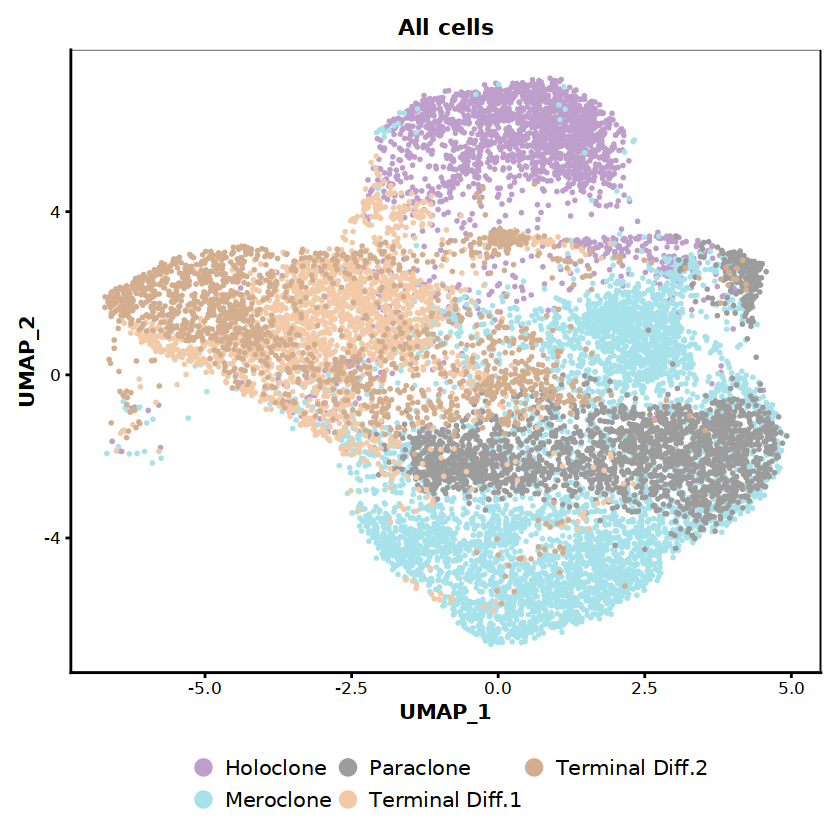

In [14]:
dims(7, 7)

p_a <- DimPlot(
    sc_query, reduction = 'umap', group.by = 'celltype_display',
    label = FALSE, pt.size = 0.4, raster = FALSE,
    cols = celltype_cmap, order = rev(celltype_levels)
) +
    guides(color = guide_legend(override.aes = list(size = 4, alpha = 1), nrow = 2)) +
    labs(title = 'All cells') +
    umap_theme()
p_a

ggsave(file.path(out_dir, 'fig10a_umap_all_cells.svg'),
       plot = p_a, width = 7, height = 7, bg = 'white', device = 'svg')

## Panel b — UMAP, LQ-FL cells only

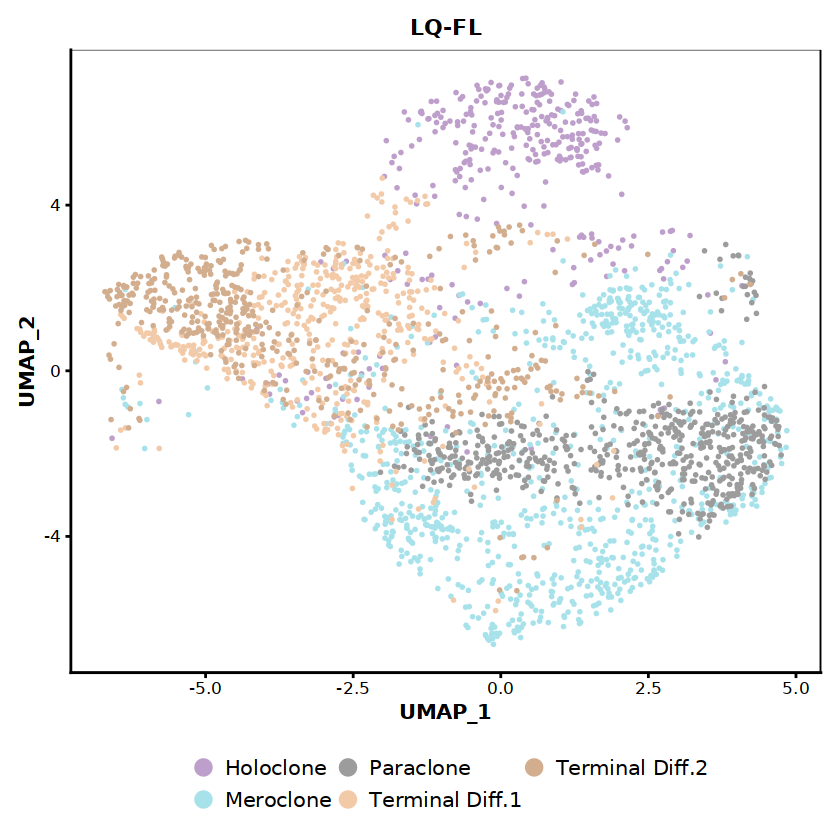

In [15]:
dims(7, 7)

lq_cells <- WhichCells(sc_query, expression = condition_display == 'LQ-FL')
p_b <- DimPlot(
    sc_query, reduction = 'umap', group.by = 'celltype_display',
    cells = lq_cells,
    label = FALSE, pt.size = 0.4, raster = FALSE,
    cols = celltype_cmap, order = rev(celltype_levels)
) +
    guides(color = guide_legend(override.aes = list(size = 4, alpha = 1), nrow = 2)) +
    labs(title = 'LQ-FL') +
    umap_theme()
p_b

ggsave(file.path(out_dir, 'fig10b_umap_LQ-FL.svg'),
       plot = p_b, width = 7, height = 7, bg = 'white', device = 'svg')

## Panel c — UMAP, SQ-FL cells only

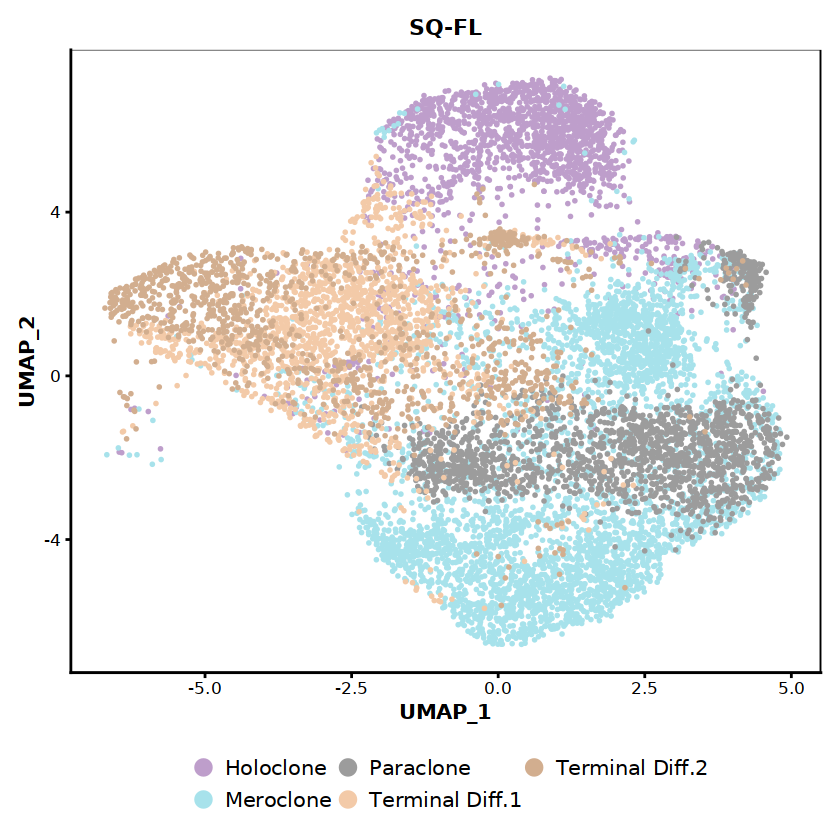

In [16]:
dims(7, 7)

sq_cells <- WhichCells(sc_query, expression = condition_display == 'SQ-FL')
p_c <- DimPlot(
    sc_query, reduction = 'umap', group.by = 'celltype_display',
    cells = sq_cells,
    label = FALSE, pt.size = 0.4, raster = FALSE,
    cols = celltype_cmap, order = rev(celltype_levels)
) +
    guides(color = guide_legend(override.aes = list(size = 4, alpha = 1), nrow = 2)) +
    labs(title = 'SQ-FL') +
    umap_theme()
p_c

ggsave(file.path(out_dir, 'fig10c_umap_SQ-FL.svg'),
       plot = p_c, width = 7, height = 7, bg = 'white', device = 'svg')

## Panel d — Marker dot plot

Default Seurat `DotPlot` z-scores mean expression per gene across groups, which matches the
manuscript colorbar (-1 to 1, white → red). Genes ordered left-to-right as in the figure.

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


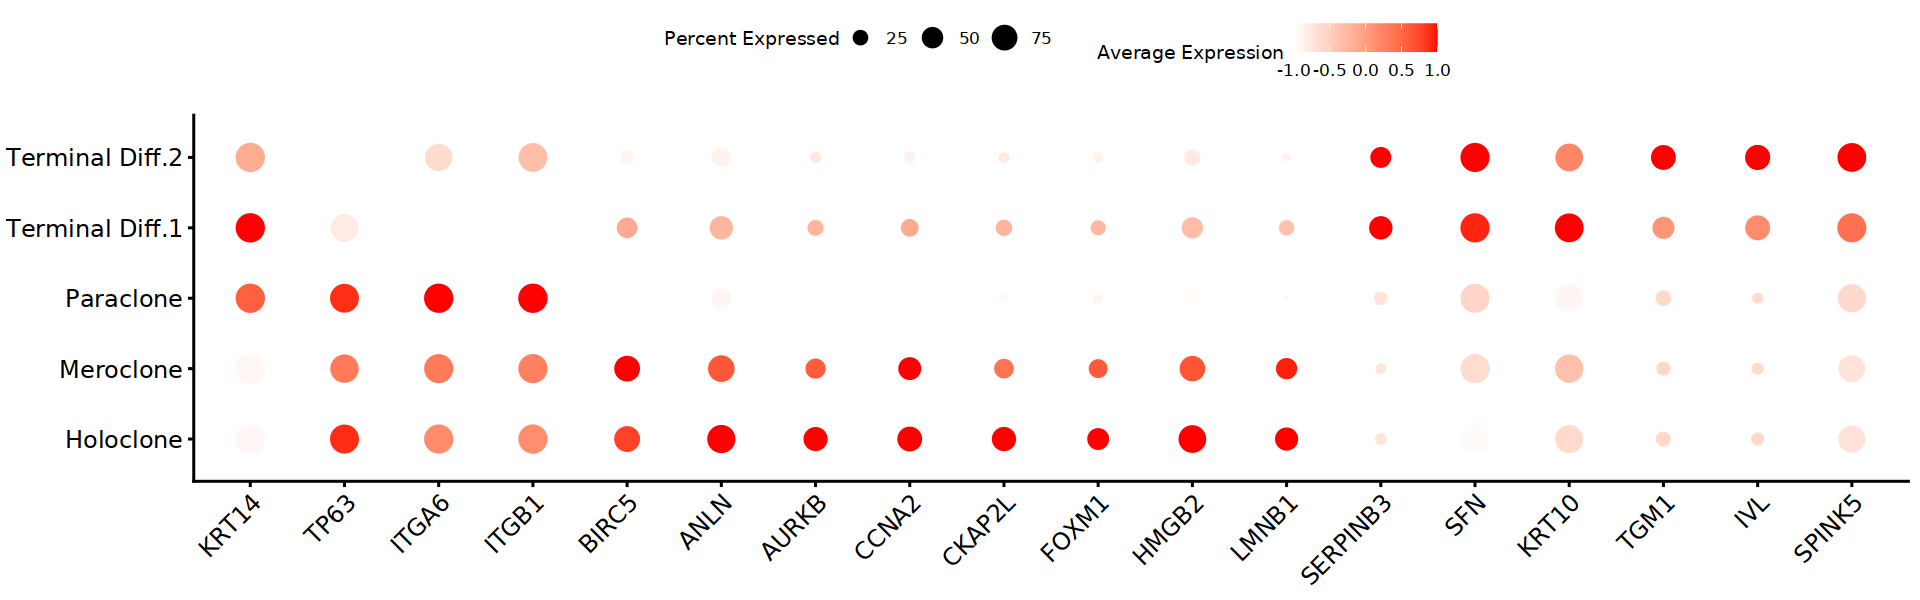

In [17]:
dims(16, 5)

marker_genes <- c(
    'KRT14', 'TP63', 'ITGA6', 'ITGB1', 'BIRC5', 'ANLN', 'AURKB', 'CCNA2',
    'CKAP2L', 'FOXM1', 'HMGB2', 'LMNB1', 'SERPINB3', 'SFN', 'KRT10', 'TGM1',
    'IVL', 'SPINK5'
)

# Cluster order top -> bottom in the figure
celltype_order_dotplot <- c('Holoclone', 'Meroclone', 'Paraclone',
                            'Terminal Diff.1', 'Terminal Diff.2')
sc_query$celltype_display <- factor(sc_query$celltype_display,
                                    levels = celltype_order_dotplot)

# Sanity check on marker genes
missing_markers <- setdiff(marker_genes, rownames(sc_query[['RNA']]))
if (length(missing_markers) > 0) {
    warning('Markers not in RNA assay: ', paste(missing_markers, collapse = ', '))
}
markers_present <- intersect(marker_genes, rownames(sc_query[['RNA']]))

p_d <- DotPlot(
    sc_query,
    assay    = 'RNA',
    group.by = 'celltype_display',
    features = markers_present
) +
    # Diverging white -> red gradient on the z-scored avg.exp.scaled values (-1 to 1).
    # Below -1 clips to white; above +1 clips to red.
    scale_colour_gradient2(
        low      = 'white',
        mid      = 'white',
        high     = 'red',
        midpoint = -1,
        limits   = c(-1, 1),
        oob      = scales::squish,
        name     = 'Mean expression\nin group'
    ) +
    scale_size(name = 'Fraction of cells\nin group (%)', range = c(0, 7)) +
    labs(x = NULL, y = NULL) +
    theme_classic(base_size = 14) +
    theme(
        axis.text.x        = element_text(angle = 45, hjust = 1, size = 14,
                                          face = 'italic', color = 'black'),
        axis.text.y        = element_text(size = 14, color = 'black'),
        legend.position    = 'top',
        legend.box         = 'horizontal',
        legend.title       = element_text(size = 11),
        legend.text        = element_text(size = 10)
    )
p_d

ggsave(file.path(out_dir, 'fig10d_marker_dotplot.svg'),
       plot = p_d, width = 16, height = 5, bg = 'white', device = 'svg')

## Panel e — % cells per cluster, by condition, with per-sample dots

For each (sample, cluster) pair, compute `% cells = 100 * count / sample total`. Bars show
the per-condition mean across the two replicates; dots show each replicate individually
(K74 / K86).

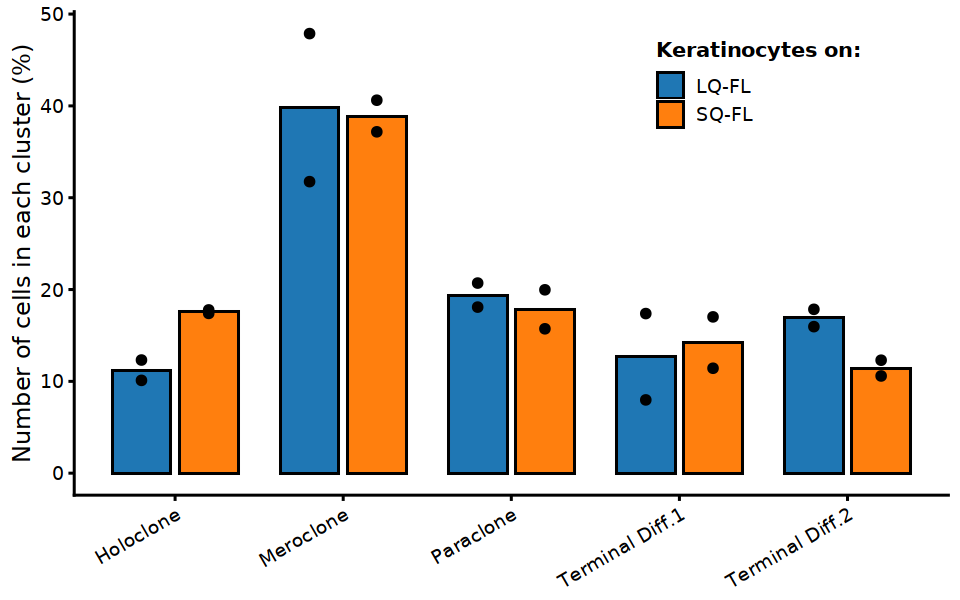

In [18]:
dims(8, 5)

# Per-sample percentages
meta_df <- sc_query@meta.data %>%
    transmute(
        sample    = as.character(orig.ident),
        celltype  = celltype_display,
        condition = condition_display
    )

per_sample_pct <- meta_df %>%
    group_by(sample, condition, celltype) %>%
    summarise(n = n(), .groups = 'drop') %>%
    group_by(sample) %>%
    mutate(pct = 100 * n / sum(n)) %>%
    ungroup() %>%
    # Make sure every (sample, celltype) cell exists even when count = 0,
    # otherwise missing zeros would skew the per-condition mean.
    complete(sample, celltype, fill = list(n = 0, pct = 0)) %>%
    # Re-attach condition where it got dropped by `complete`
    group_by(sample) %>%
    mutate(condition = unique(na.omit(condition))) %>%
    ungroup()

# Per-condition mean across replicates
per_condition_mean <- per_sample_pct %>%
    group_by(condition, celltype) %>%
    summarise(pct_mean = mean(pct), .groups = 'drop')

# Order x-axis as in the figure
celltype_order_bar <- c('Holoclone', 'Meroclone', 'Paraclone',
                        'Terminal Diff.1', 'Terminal Diff.2')
per_sample_pct$celltype     <- factor(per_sample_pct$celltype,     levels = celltype_order_bar)
per_condition_mean$celltype <- factor(per_condition_mean$celltype, levels = celltype_order_bar)

p_e <- ggplot() +
    geom_bar(
        data    = per_condition_mean,
        aes(x = celltype, y = pct_mean, fill = condition),
        stat    = 'identity', position = position_dodge(width = 0.8),
        width   = 0.7, color = 'black'
    ) +
    geom_point(
        data    = per_sample_pct,
        aes(x = celltype, y = pct, group = condition),
        position = position_dodge(width = 0.8),
        size = 2, color = 'black'
    ) +
    scale_fill_manual(
        values = condition_cmap,
        name   = 'Keratinocytes on:',
        breaks = condition_levels
    ) +
    labs(x = NULL, y = 'Number of cells in each cluster (%)') +
    theme_classic(base_size = 14) +
    theme(
        axis.text.x        = element_text(angle = 30, hjust = 1, color = 'black'),
        axis.text.y        = element_text(color = 'black'),
        axis.line          = element_line(color = 'black'),
        legend.position    = c(0.78, 0.85),
        legend.background  = element_rect(fill = 'white', color = NA),
        legend.title       = element_text(size = 12, face = 'bold')
    )
p_e

ggsave(file.path(out_dir, 'fig10e_percent_cells_per_cluster.svg'),
       plot = p_e, width = 8, height = 5, bg = 'white', device = 'svg')
write.csv(per_sample_pct, file.path(out_dir, 'fig10e_source_data.csv'), row.names = FALSE)